In [38]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [39]:
from scripts.data_loader import (
    load_proact_alsfrs,
    load_proact_demographics,
    load_proact_als_history,
    load_proact_deathdata,
    load_proact_treatment,
    load_targetals_agri_clinical
)

from scripts.preprocessing import standardize_columns

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [42]:
alsfrs = load_proact_alsfrs()
demo = load_proact_demographics()
hist = load_proact_als_history()
death = load_proact_deathdata()
treat = load_proact_treatment()
agri = load_targetals_agri_clinical()

In [43]:
alsfrs_s = standardize_columns(alsfrs)
demo_s = standardize_columns(demo)
hist_s = standardize_columns(hist)
death_s = standardize_columns(death)
treat_s = standardize_columns(treat)
agri_s = standardize_columns(agri)

In [44]:
print("ALSFRS columns:")
print(list(alsfrs_s.columns))

print("\nDemographics columns:")
print(list(demo_s.columns))

print("\nALS history columns:")
print(list(hist_s.columns))

ALSFRS columns:
['subject_id', 'q1_speech', 'q2_salivation', 'q3_swallowing', 'q4_handwriting', 'q5a_cutting_without_gastrostomy', 'q5b_cutting_with_gastrostomy', 'q6_dressing_and_hygiene', 'q7_turning_in_bed', 'q8_walking', 'q9_climbing_stairs', 'q10_respiratory', 'alsfrs_delta', 'alsfrs_total', 'alsfrs_r_total', 'r_1_dyspnea', 'r_2_orthopnea', 'r_3_respiratory_insufficiency', 'mode_of_administration', 'alsfrs_responded_by']

Demographics columns:
['subject_id', 'demographics_delta', 'age', 'date_of_birth', 'ethnicity', 'race_americ_indian_alaska_native', 'race_asian', 'race_black_african_american', 'race_hawaiian_pacific_islander', 'race_unknown', 'race_caucasian', 'race_other', 'race_other_specify', 'sex']

ALS history columns:
['subject_id', 'site_of_onset___bulbar', 'site_of_onset___limb', 'site_of_onset___limb_and_bulbar', 'site_of_onset___other', 'site_of_onset___other_specify', 'site_of_onset___spine', 'subject_als_history_delta', 'disease_duration', 'symptom', 'symptom_other_s

In [45]:
patient_col = "subject_id"
time_col = "alsfrs_delta"
target_col = "alsfrs_r_total"

week4_path = repo_root / "data" / "processed" / "alsfrs_longitudinal_week4.csv"

if week4_path.exists():
    week4_df = pd.read_csv(week4_path)
else:
    week4_df = alsfrs_s[[patient_col, time_col, target_col]].copy()
    week4_df[time_col] = pd.to_numeric(week4_df[time_col], errors="coerce")
    week4_df[target_col] = pd.to_numeric(week4_df[target_col], errors="coerce")
    week4_df = week4_df.dropna(subset=[patient_col, time_col, target_col])
    week4_df = week4_df.sort_values([patient_col, time_col]).copy()

week4_df.head(), week4_df.shape

(   subject_id  alsfrs_delta  alsfrs_r_total
 0        3301           5.0            35.0
 1        3301          40.0            34.0
 2        3301          98.0            32.0
 3        3301         161.0            32.0
 4        3301         221.0            34.0,
 (51903, 3))

In [46]:
week4_df[time_col] = pd.to_numeric(week4_df[time_col], errors="coerce")
week4_df[target_col] = pd.to_numeric(week4_df[target_col], errors="coerce")

week4_df = week4_df.dropna(subset=[patient_col, time_col, target_col]).copy()
week4_df = week4_df.drop_duplicates(subset=[patient_col, time_col]).copy()
week4_df = week4_df.sort_values([patient_col, time_col]).copy()

print("Rows:", len(week4_df))
print("Unique patients:", week4_df[patient_col].nunique())
week4_df.head()

Rows: 51888
Unique patients: 6047


,subject_id,alsfrs_delta,alsfrs_r_total
0,3301,5.0,35.0
1,3301,40.0,34.0
2,3301,98.0,32.0
3,3301,161.0,32.0
4,3301,221.0,34.0


In [47]:
def first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

In [48]:
age_col = first_existing_column(demo_s, [
    "age",
    "age_at_baseline",
    "baseline_age"
])

sex_col = first_existing_column(demo_s, [
    "sex",
    "gender"
])

onset_delta_col = first_existing_column(hist_s, [
    "onset_delta",
    "disease_duration",
    "symptom_duration",
    "time_since_onset"
])

site_onset_col = first_existing_column(hist_s, [
    "site_of_onset",
    "onset_site",
    "site_onset"
])

print("Selected age column:", age_col)
print("Selected sex column:", sex_col)
print("Selected onset delta column:", onset_delta_col)
print("Selected site of onset column:", site_onset_col)

Selected age column: age
Selected sex column: sex
Selected onset delta column: onset_delta
Selected site of onset column: site_of_onset


In [49]:
demo_feature_cols = [patient_col]
if age_col is not None:
    demo_feature_cols.append(age_col)
if sex_col is not None:
    demo_feature_cols.append(sex_col)

hist_feature_cols = [patient_col]
if onset_delta_col is not None:
    hist_feature_cols.append(onset_delta_col)
if site_onset_col is not None:
    hist_feature_cols.append(site_onset_col)

demo_features = demo_s[demo_feature_cols].drop_duplicates(subset=[patient_col]).copy()
hist_features = hist_s[hist_feature_cols].drop_duplicates(subset=[patient_col]).copy()

print("Demo feature table shape:", demo_features.shape)
print("History feature table shape:", hist_features.shape)
display(demo_features.head())
display(hist_features.head())

Demo feature table shape: (13115, 3)
History feature table shape: (11656, 3)


,subject_id,age,sex
0,204,67.0,Female
1,1904,46.0,Male
2,3301,NaN,Male
3,3650,55.0,Female
4,3752,75.0,Female


,subject_id,onset_delta,site_of_onset
0,204,-401.0,NaN
1,3301,-1049.0,Onset: Limb
2,3650,NaN,Onset: Limb
4,3752,-901.0,NaN
5,4919,NaN,NaN


In [50]:
model_df = week4_df.merge(demo_features, on=patient_col, how="left")
model_df = model_df.merge(hist_features, on=patient_col, how="left")

print("Merged modeling dataframe shape:", model_df.shape)
model_df.head()

Merged modeling dataframe shape: (51888, 7)


,subject_id,alsfrs_delta,alsfrs_r_total,age,sex,onset_delta,site_of_onset
0,3301,5.0,35.0,NaN,Male,-1049.0,Onset: Limb
1,3301,40.0,34.0,NaN,Male,-1049.0,Onset: Limb
2,3301,98.0,32.0,NaN,Male,-1049.0,Onset: Limb
3,3301,161.0,32.0,NaN,Male,-1049.0,Onset: Limb
4,3301,221.0,34.0,NaN,Male,-1049.0,Onset: Limb


In [51]:
model_df = model_df.sort_values([patient_col, time_col]).copy()

model_df["visit_number"] = model_df.groupby(patient_col).cumcount() + 1
model_df["baseline_alsfrs_r_total"] = model_df.groupby(patient_col)[target_col].transform("first")
model_df["prev_alsfrs_r_total"] = model_df.groupby(patient_col)[target_col].shift(1)
model_df["prev_alsfrs_delta"] = model_df.groupby(patient_col)[time_col].shift(1)

model_df["time_since_first_visit"] = (
    model_df[time_col] - model_df.groupby(patient_col)[time_col].transform("first")
)

model_df["delta_from_prev_visit"] = model_df[time_col] - model_df["prev_alsfrs_delta"]
model_df["change_from_baseline"] = model_df[target_col] - model_df["baseline_alsfrs_r_total"]
model_df["change_from_prev_visit"] = model_df[target_col] - model_df["prev_alsfrs_r_total"]

model_df.head(10)

,subject_id,alsfrs_delta,alsfrs_r_total,age,sex,onset_delta,site_of_onset,visit_number,baseline_alsfrs_r_total,prev_alsfrs_r_total,prev_alsfrs_delta,time_since_first_visit,delta_from_prev_visit,change_from_baseline,change_from_prev_visit
0,3301,5.0,35.0,NaN,Male,-1049.0,Onset: Limb,1,35.0,NaN,NaN,0.0,NaN,0.0,NaN
1,3301,40.0,34.0,NaN,Male,-1049.0,Onset: Limb,2,35.0,35.0,5.0,35.0,35.0,-1.0,-1.0
2,3301,98.0,32.0,NaN,Male,-1049.0,Onset: Limb,3,35.0,34.0,40.0,93.0,58.0,-3.0,-2.0
3,3301,161.0,32.0,NaN,Male,-1049.0,Onset: Limb,4,35.0,32.0,98.0,156.0,63.0,-3.0,0.0
4,3301,221.0,34.0,NaN,Male,-1049.0,Onset: Limb,5,35.0,32.0,161.0,216.0,60.0,-1.0,2.0
5,3301,273.0,32.0,NaN,Male,-1049.0,Onset: Limb,6,35.0,34.0,221.0,268.0,52.0,-3.0,-2.0
6,6787,0.0,35.0,50.0,Male,-585.0,Onset: Limb,1,35.0,NaN,NaN,0.0,NaN,0.0,NaN
7,6787,25.0,34.0,50.0,Male,-585.0,Onset: Limb,2,35.0,35.0,0.0,25.0,25.0,-1.0,-1.0
8,6787,59.0,31.0,50.0,Male,-585.0,Onset: Limb,3,35.0,34.0,25.0,59.0,34.0,-4.0,-3.0
9,6787,91.0,26.0,50.0,Male,-585.0,Onset: Limb,4,35.0,31.0,59.0,91.0,32.0,-9.0,-5.0


In [52]:
missing_summary = (
    model_df.isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_fraction")
    .reset_index()
)

missing_summary.columns = ["column", "missing_fraction"]
missing_summary.head(20)

,column,missing_fraction
0,site_of_onset,0.335839
1,age,0.124364
2,prev_alsfrs_r_total,0.116539
3,prev_alsfrs_delta,0.116539
4,delta_from_prev_visit,0.116539
5,change_from_prev_visit,0.116539
6,onset_delta,0.033958
7,subject_id,0.000000
8,alsfrs_delta,0.000000
9,alsfrs_r_total,0.000000


In [53]:
model_df = model_df[model_df["prev_alsfrs_r_total"].notna()].copy()

print("Rows after requiring previous visit:", len(model_df))
print("Unique patients after requiring previous visit:", model_df[patient_col].nunique())
model_df.head()

Rows after requiring previous visit: 45841
Unique patients after requiring previous visit: 5704


,subject_id,alsfrs_delta,alsfrs_r_total,age,sex,onset_delta,site_of_onset,visit_number,baseline_alsfrs_r_total,prev_alsfrs_r_total,prev_alsfrs_delta,time_since_first_visit,delta_from_prev_visit,change_from_baseline,change_from_prev_visit
1,3301,40.0,34.0,NaN,Male,-1049.0,Onset: Limb,2,35.0,35.0,5.0,35.0,35.0,-1.0,-1.0
2,3301,98.0,32.0,NaN,Male,-1049.0,Onset: Limb,3,35.0,34.0,40.0,93.0,58.0,-3.0,-2.0
3,3301,161.0,32.0,NaN,Male,-1049.0,Onset: Limb,4,35.0,32.0,98.0,156.0,63.0,-3.0,0.0
4,3301,221.0,34.0,NaN,Male,-1049.0,Onset: Limb,5,35.0,32.0,161.0,216.0,60.0,-1.0,2.0
5,3301,273.0,32.0,NaN,Male,-1049.0,Onset: Limb,6,35.0,34.0,221.0,268.0,52.0,-3.0,-2.0


In [54]:
candidate_feature_cols = [
    time_col,
    "visit_number",
    "baseline_alsfrs_r_total",
    "prev_alsfrs_r_total",
    "time_since_first_visit",
    "delta_from_prev_visit",
    age_col,
    sex_col,
    onset_delta_col,
    site_onset_col
]

feature_cols = [col for col in candidate_feature_cols if col is not None and col in model_df.columns]

print("Feature columns:")
print(feature_cols)

Feature columns:
['alsfrs_delta', 'visit_number', 'baseline_alsfrs_r_total', 'prev_alsfrs_r_total', 'time_since_first_visit', 'delta_from_prev_visit', 'age', 'sex', 'onset_delta', 'site_of_onset']


In [55]:
modeling_df = model_df[[patient_col] + feature_cols + [target_col]].copy()

print("Final modeling dataset shape:", modeling_df.shape)
modeling_df.head()

Final modeling dataset shape: (45841, 12)


,subject_id,alsfrs_delta,visit_number,baseline_alsfrs_r_total,prev_alsfrs_r_total,time_since_first_visit,delta_from_prev_visit,age,sex,onset_delta,site_of_onset,alsfrs_r_total
1,3301,40.0,2,35.0,35.0,35.0,35.0,NaN,Male,-1049.0,Onset: Limb,34.0
2,3301,98.0,3,35.0,34.0,93.0,58.0,NaN,Male,-1049.0,Onset: Limb,32.0
3,3301,161.0,4,35.0,32.0,156.0,63.0,NaN,Male,-1049.0,Onset: Limb,32.0
4,3301,221.0,5,35.0,32.0,216.0,60.0,NaN,Male,-1049.0,Onset: Limb,34.0
5,3301,273.0,6,35.0,34.0,268.0,52.0,NaN,Male,-1049.0,Onset: Limb,32.0


In [56]:
week5_output_path = repo_root / "data" / "processed" / "alsfrs_modeling_week5.csv"
modeling_df.to_csv(week5_output_path, index=False)

In [57]:
patients = modeling_df[patient_col].dropna().unique()

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.2,
    random_state=42
)

train_df = modeling_df[modeling_df[patient_col].isin(train_patients)].copy()
test_df = modeling_df[modeling_df[patient_col].isin(test_patients)].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train patients:", train_df[patient_col].nunique())
print("Test patients:", test_df[patient_col].nunique())

Train rows: 36623
Test rows: 9218
Train patients: 4563
Test patients: 1141


In [58]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

In [59]:
naive_pred = test_df["prev_alsfrs_r_total"]

naive_mae = mean_absolute_error(y_test, naive_pred)
naive_rmse = rmse_score(y_test, naive_pred)
naive_r2 = r2_score(y_test, naive_pred)

print("Naive baseline MAE:", round(naive_mae, 4))
print("Naive baseline RMSE:", round(naive_rmse, 4))
print("Naive baseline R^2:", round(naive_r2, 4))

Naive baseline MAE: 1.9398
Naive baseline RMSE: 3.0123
Naive baseline R^2: 0.8822


In [60]:
numeric_features = []
categorical_features = []

for col in feature_cols:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['alsfrs_delta', 'visit_number', 'baseline_alsfrs_r_total', 'prev_alsfrs_r_total', 'time_since_first_visit', 'delta_from_prev_visit', 'age', 'onset_delta']
Categorical features: ['sex', 'site_of_onset']


In [61]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [62]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = rmse_score(y_test, linear_pred)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression MAE:", round(linear_mae, 4))
print("Linear Regression RMSE:", round(linear_rmse, 4))
print("Linear Regression R^2:", round(linear_r2, 4))

Linear Regression MAE: 1.8298
Linear Regression RMSE: 2.6188
Linear Regression R^2: 0.9109


In [63]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = rmse_score(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", round(rf_mae, 4))
print("Random Forest RMSE:", round(rf_rmse, 4))
print("Random Forest R^2:", round(rf_r2, 4))

Random Forest MAE: 1.8218
Random Forest RMSE: 2.5995
Random Forest R^2: 0.9122


In [64]:
metrics_df = pd.DataFrame([
    {
        "model_name": "naive_previous_visit",
        "mae": naive_mae,
        "rmse": naive_rmse,
        "r2": naive_r2,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_patients": train_df[patient_col].nunique(),
        "n_test_patients": test_df[patient_col].nunique()
    },
    {
        "model_name": "linear_regression",
        "mae": linear_mae,
        "rmse": linear_rmse,
        "r2": linear_r2,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_patients": train_df[patient_col].nunique(),
        "n_test_patients": test_df[patient_col].nunique()
    },
    {
        "model_name": "random_forest",
        "mae": rf_mae,
        "rmse": rf_rmse,
        "r2": rf_r2,
        "n_train_rows": len(train_df),
        "n_test_rows": len(test_df),
        "n_train_patients": train_df[patient_col].nunique(),
        "n_test_patients": test_df[patient_col].nunique()
    }
])

metrics_df

,model_name,mae,rmse,r2,n_train_rows,n_test_rows,n_train_patients,n_test_patients
0,naive_previous_visit,1.939792,3.012288,0.882153,36623,9218,4563,1141
1,linear_regression,1.829816,2.618816,0.910929,36623,9218,4563,1141
2,random_forest,1.821809,2.599467,0.912241,36623,9218,4563,1141


In [65]:
metrics_path = repo_root / "reports" / "week5_baseline_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

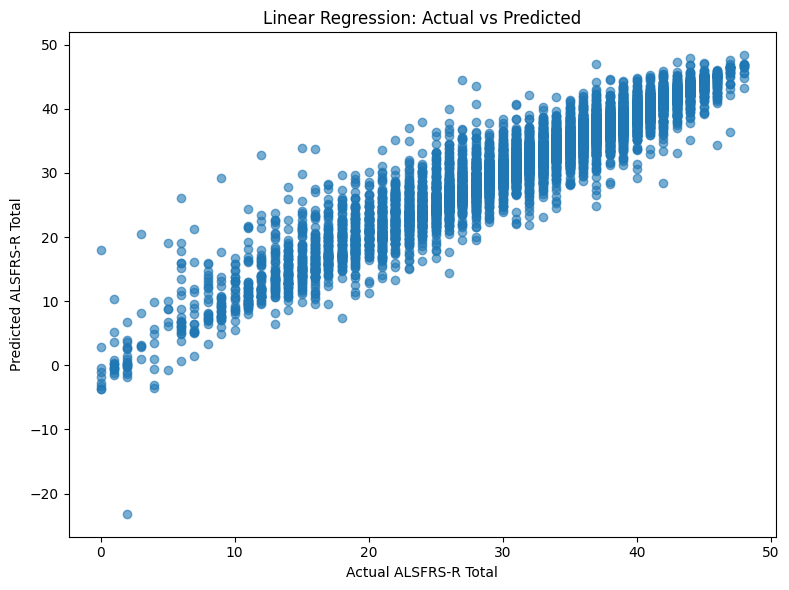

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred, alpha=0.6)
plt.xlabel("Actual ALSFRS-R Total")
plt.ylabel("Predicted ALSFRS-R Total")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.savefig(repo_root / "figures" / "week5_actual_vs_predicted_linear.png", dpi=300)
plt.show()

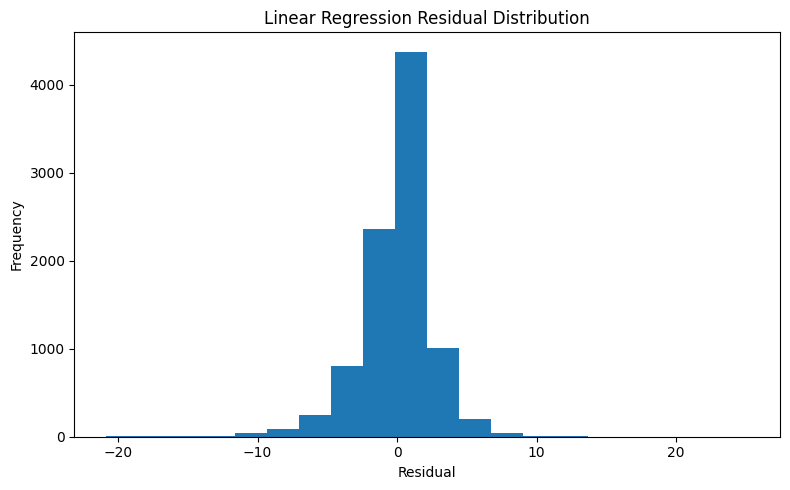

In [71]:
linear_residuals = y_test - linear_pred

plt.figure(figsize=(8, 5))
plt.hist(linear_residuals, bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Linear Regression Residual Distribution")
plt.tight_layout()
plt.savefig(repo_root / "figures" / "week5_residuals_linear.png", dpi=300)
plt.show()

In [72]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_estimator = rf_model.named_steps["model"]

encoded_feature_names = rf_preprocessor.get_feature_names_out()
feature_importance_df = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": rf_estimator.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
3,num__prev_alsfrs_r_total,0.977097
5,num__delta_from_prev_visit,0.013455
7,num__onset_delta,0.003403
2,num__baseline_alsfrs_r_total,0.001911
6,num__age,0.001227
0,num__alsfrs_delta,0.000918
4,num__time_since_first_visit,0.000870
1,num__visit_number,0.000585
10,cat__site_of_onset_Onset: Bulbar,0.000124
11,cat__site_of_onset_Onset: Limb,0.000090


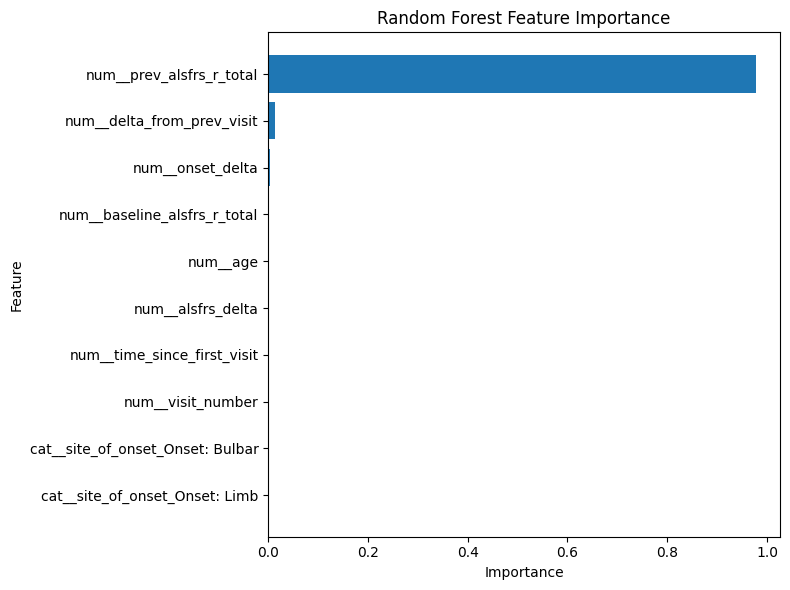

In [73]:
top_features = feature_importance_df.head(10).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(repo_root / "figures" / "week5_feature_importance_rf.png", dpi=300)
plt.show()